<a href="https://colab.research.google.com/github/nguyendanh31251025606-eng/NOP_BTVN/blob/main/nopbtvn1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#23.1
import folium
ueh_coords = [10.761158591008995, 106.66836872262138]
m = folium.Map(location=ueh_coords, zoom_start=14)
folium.Marker(
    ueh_coords,
    popup="Đại học Kinh tế TP.HCM (UEH)",
    tooltip="Click để xem chi tiết",
    icon=folium.Icon(color='green', icon='university',prefix='fa')).add_to(m)
locations = [
    {"name": "Bệnh viện chợ rẫy", "coords": [10.758104537786622, 106.65977409629737], "type": "Bệnh Viện"},
    {"name": "Vạn Hạnh Mall", "coords": [10.770690727495419, 106.67011054841386], "type": "Trung tâm thương mại"},
    {"name": "Công Viên Hòa Bình", "coords": [10.760571857725472, 106.67369759167477], "type": "Công viên"}
]
for loc in locations:
    folium.Marker(
        loc["coords"],
        popup=f"{loc['name']} ({loc['type']})",
        icon=folium.Icon(color='blue')
    ).add_to(m)
m

In [ ]:
#23.2
import folium
center_pt = (10.7720, 106.6983)
places = [
    ("Bitexco Financial Tower", (10.7717, 106.7041)),
    ("Notre Dame Cathedral", (10.7798, 106.6992)),
    ("War Remnants Museum", (10.7795, 106.6920)),
    ("Independence Palace", (10.7769, 106.6953)),
    ("Saigon Opera House", (10.7765, 106.7030)),
    ("Landmark 81", (10.7942, 106.7218)),
    ("Cho An Dong", (10.7553, 106.6654)),
    ("HCMUT", (10.7734, 106.6602)),
    ("Thong Nhat Stadium", (10.7630, 106.6646)),
    ("Saigon Zoo", (10.7870, 106.7057))
]
m = folium.Map(location=center_pt, zoom_start=13)
folium.Marker(center_pt, popup="Ben Thanh", icon=folium.Icon(color="red")).add_to(m)
for name, pt in places:
    folium.Marker(pt, popup=name).add_to(m)
    folium.PolyLine([center_pt, pt], color="blue").add_to(m)
m

In [ ]:
#23.3
import folium
from folium.plugins import HeatMap
m = folium.Map(location=[10.775, 106.700], zoom_start=14)
delivery_points = [
    [10.775, 106.700], [10.775, 106.701], [10.774, 106.700],
    [10.781, 106.702], [10.780, 106.702],
    [10.770, 106.695], [10.771, 106.696]
]
HeatMap(delivery_points, radius=15, blur=10).add_to(m)
m.save("heatmap.html")
m

In [ ]:
#23.4
import geopandas as gpd
import pandas as pd
import folium
map_data = gpd.read_file("phuong_hcm.geojson")
if "ten_phuong" not in map_data.columns:
    if "name" in map_data.columns:
        map_data = map_data.rename(columns={"name": "ten_phuong"})
data = pd.DataFrame({
    "ten_phuong": map_data["ten_phuong"].values,
    "don_hang": [120, 80, 150, 200, 95, 60][:len(map_data)]
})
m = folium.Map(location=[10.76, 106.68], zoom_start=13)
folium.Choropleth(
    geo_data=map_data,
    data=data,
    columns=["ten_phuong", "don_hang"],
    key_on="feature.properties.ten_phuong",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="Số đơn hàng"
).add_to(m)
m

In [ ]:
#23.5
import folium
center_loc = [10.775, 106.700]
m = folium.Map(location=center_loc, zoom_start=12)
service_radii = [
    {"radius": 3000, "color": "green", "label": "Vùng ưu tiên (3km)"},
    {"radius": 5000, "color": "orange", "label": "Vùng mở rộng (5km)"},
    {"radius": 10000, "color": "red", "label": "Vùng giới hạn (10km)"}
]
for area in service_radii:
    folium.Circle(
        location=center_loc,
        radius=area["radius"],
        color=area["color"],
        fill=True,
        fill_opacity=0.2,
        tooltip=area["label"]
    ).add_to(m)
folium.Marker(center_loc, popup="Trung tâm phân phối A", icon=folium.Icon(color='blue')).add_to(m)

m

Số lượng nút giao (Nodes): 989
Số lượng đoạn đường (Edges): 2090
Chiều dài đường trung bình: 79.03 mét


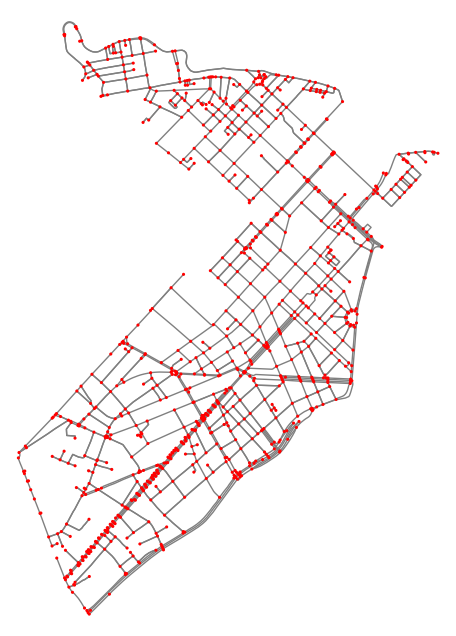

In [ ]:
#23.6
import osmnx as ox
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
graph = ox.graph_from_place(place_name, network_type='drive')
stats = ox.basic_stats(graph)
print(f"Số lượng nút giao (Nodes): {stats['n']}")
print(f"Số lượng đoạn đường (Edges): {stats['m']}")
print(f"Chiều dài đường trung bình: {stats['edge_length_avg']:.2f} mét")
fig, ax = ox.plot_graph(graph, node_size=5, node_color='r', edge_color='gray', bgcolor='white')
plt.show()

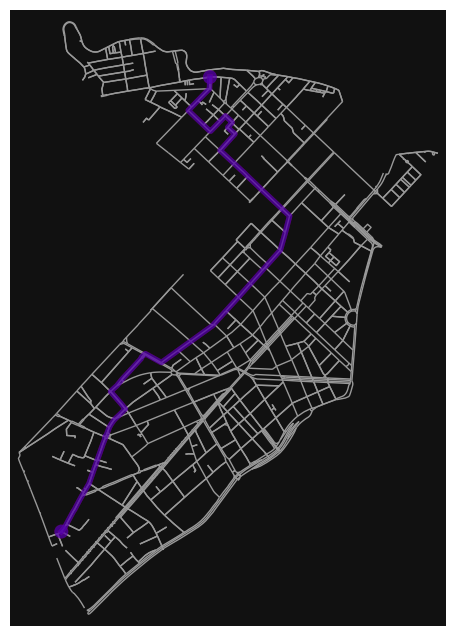

In [ ]:
#23.7
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
place_name = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place_name, network_type='drive')
nodes = list(G.nodes)
orig = nodes[0]
dest = nodes[100]
route_dijkstra = nx.shortest_path(G, orig, dest, weight='length', method='dijkstra')
route_astar = nx.astar_path(G, orig, dest, weight='length')
fig, ax = ox.plot_graph_routes(G, [route_dijkstra, route_astar],
                                route_colors=['r', 'b'],
                                route_linewidth=4,
                                node_size=0)
plt.show()

In [ ]:
#23.8
import osmnx as ox
import networkx as nx
import folium
import numpy as np

np.random.seed(36)

center = (10.7769, 106.7009)
n = 8

customers = [
    (center[0] + dx, center[1] + dy)
    for dx, dy in np.random.uniform(-0.02, 0.02, (n, 2))
]

drivers = [
    (center[0] + dx, center[1] + dy)
    for dx, dy in np.random.uniform(-0.02, 0.02, (n, 2))
]

G = ox.graph_from_point(center, dist=3000, network_type='walk')

def path(a, b):
    try:
        o = ox.distance.nearest_nodes(G, a[1], a[0])
        d = ox.distance.nearest_nodes(G, b[1], b[0])
        return nx.shortest_path_length(G, o, d, weight="length"), nx.shortest_path(G, o, d, weight="length")
    except:
        return float("inf"), []

pairs = []
free = drivers[:]

for c in customers:
    best = min(free, key=lambda x: path(c, x)[0])
    dist, r = path(c, best)
    if r:
        pairs.append((c, best, r))
        free.remove(best)

m = folium.Map(location=center, zoom_start=13)

for i, c in enumerate(customers):
    folium.Marker(c, popup=f"C{i}", icon=folium.Icon(color="red")).add_to(m)

for i, d in enumerate(drivers):
    folium.Marker(d, popup=f"D{i}", icon=folium.Icon(color="blue")).add_to(m)

for c, d, r in pairs:
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in r]
    folium.PolyLine(coords, color="black", weight=3).add_to(m)

m

In [ ]:
#23.9
import folium
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
np.random.seed(42)
centers = [(10.7769, 106.7009), (10.7300, 106.7200), (10.8200, 106.6800)]
data = []
for center in centers:
    lat = np.random.normal(center[0], 0.015, 100)
    lon = np.random.normal(center[1], 0.015, 100)
    data.extend(list(zip(lat, lon)))
df = pd.DataFrame(data, columns=['Latitude', 'Longitude'])
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])
optimal_hubs = kmeans.cluster_centers_
m = folium.Map(location=[10.7800, 106.7000], zoom_start=12, tiles='CartoDB Positron')
colors = ['blue', 'green', 'purple', 'orange', 'darkred']
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=colors[int(row['Cluster']) % len(colors)],
        fill=True,
        fill_opacity=0.6,
        weight=0
    ).add_to(m)
for i, hub in enumerate(optimal_hubs):
    popup_info = f"<b>Trạm trung chuyển #{i+1}</b><br>Vĩ độ: {hub[0]:.4f}<br>Kinh độ: {hub[1]:.4f}"

    folium.Marker(
        location=[hub[0], hub[1]],
        popup=popup_info,
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)
    folium.Circle(
        location=[hub[0], hub[1]],
        radius=2500,
        color=colors[i % len(colors)],
        fill=True,
        fill_opacity=0.1,
        weight=1.5
    ).add_to(m)
output_file = 'kmeans_hub_optimization.html'
m

In [ ]:
#23.10
import folium
from folium import plugins
import numpy as np
m = folium.Map(location=[10.7950, 106.7100], zoom_start=13, tiles='CartoDB Positron')
np.random.seed(42)
congestion_points = []
for _ in range(300):
    lat = np.random.normal(10.8000, 0.003) # Phương sai nhỏ -> tập trung dày đặc
    lon = np.random.normal(10.7110, 0.003)
    congestion_points.append([lat, lon])
fg_risk = folium.FeatureGroup(name="🔥 Vùng rủi ro (Heatmap)")
plugins.HeatMap(
    congestion_points,
    radius=15,
    blur=10,
    gradient={0.4: 'yellow', 0.65: 'orange', 1: 'red'}
).add_to(fg_risk)
m.add_child(fg_risk)
kho_q1 = [10.7800, 106.7000]
diem_den_thuduc = [10.8100, 106.7300]
hang_xanh = [10.8000, 106.7110]
cau_thu_thiem = [10.7870, 106.7180]
fg_routes = folium.FeatureGroup(name=" Tuyến đường phân tích")
folium.Marker(kho_q1, icon=folium.Icon(color='blue', icon='truck', prefix='fa'), popup="Kho Quận 1").add_to(fg_routes)
folium.Marker(diem_den_thuduc, icon=folium.Icon(color='green', icon='check', prefix='fa'), popup="Điểm giao (Thủ Đức)").add_to(fg_routes)
route_direct = [kho_q1, hang_xanh, diem_den_thuduc]
folium.PolyLine(
    locations=route_direct,
    color='red',
    weight=4,
    dash_array='10',
    opacity=0.7,
    popup="<b>Tuyến cũ (Trực tiếp)</b><br>Khoảng cách: 4.5 km<br><span style='color:red;'>CẢNH BÁO: Đi qua Vùng ùn tắc nghiêm trọng</span>"
).add_to(fg_routes)
route_alternative = [kho_q1, cau_thu_thiem, [10.8000, 106.7350], diem_den_thuduc]
folium.PolyLine(
    locations=route_alternative,
    color='green',
    weight=5,
    opacity=0.9,
    popup="<b>Tuyến đề xuất (Thay thế)</b><br>Khoảng cách: 5.2 km<br><span style='color:green;'>TỐI ƯU: Đường thông thoáng, tiết kiệm 15 phút</span>"
).add_to(fg_routes)
m.add_child(fg_routes)
folium.LayerControl(collapsed=False).add_to(m)
output_file = 'traffic_risk_rerouting.html'
m

In [ ]:
#23.11
import folium
from folium.plugins import HeatMapWithTime
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
X_train = np.array([[8, 1], [12, 0], [18, 0], [22, 1]])
y_train = np.array([500, 800, 750, 300])

model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
np.random.seed(42)
m = folium.Map(location=[10.7769, 106.7009], zoom_start=12, tiles='CartoDB Positron')
time_index = [f"{str(h).zfill(2)}:00" for h in range(24)]
heat_data = []
for h in range(24):
    pts = []
    if 7 <= h <= 9:
        for _ in range(150): pts.append([np.random.normal(10.73, 0.02), np.random.normal(106.72, 0.02)]) # Q7
        for _ in range(100): pts.append([np.random.normal(10.80, 0.02), np.random.normal(106.65, 0.02)]) # Tân Bình
    elif 11 <= h <= 13 or 17 <= h <= 19:
        for _ in range(300): pts.append([np.random.normal(10.776, 0.015), np.random.normal(106.700, 0.015)]) # Q1
    else:
        for _ in range(50): pts.append([np.random.normal(10.77, 0.05), np.random.normal(106.70, 0.05)]) # Rải rác

    heat_data.append(pts)
HeatMapWithTime(
    heat_data,
    index=time_index,
    auto_play=True,
    radius=30,
    min_opacity=0.3,
    max_opacity=0.8,
    gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1: 'red'}
).add_to(m)
output_file = 'demand_prediction_heatmap_fixed.html'
m

In [ ]:
#23.12
import osmnx as ox
import networkx as nx
import folium
import numpy as np

np.random.seed(36)

center = (10.7769, 106.7009)

offsets = np.array([[0.01, 0.01], [-0.015, 0.005], [0.005, -0.02]])
depots = [tuple(np.array(center) + o) for o in offsets]

customers = [
    (center[0] + np.random.uniform(-0.03, 0.03),
     center[1] + np.random.uniform(-0.03, 0.03))
    for _ in range(20)
]

G = ox.graph_from_point(center, dist=3000, network_type='drive')

def node(p):
    return ox.distance.nearest_nodes(G, p[1], p[0])

def dist(a, b):
    try:
        return nx.shortest_path_length(G, node(a), node(b), weight="length")
    except:
        return float("inf")

clusters = [[] for _ in depots]

for c in customers:
    d = [dist(c, depot) for depot in depots]
    if min(d) != float("inf"):
        clusters[np.argmin(d)].append(c)

routes = []

for i, depot in enumerate(depots):
    remain = clusters[i][:]
    path_nodes = []
    cur = depot

    while remain:
        nxt = min(remain, key=lambda x: dist(cur, x))
        if dist(cur, nxt) == float("inf"):
            remain.remove(nxt)
            continue

        sp = nx.shortest_path(G, node(cur), node(nxt), weight="length")
        path_nodes += sp
        cur = nxt
        remain.remove(nxt)

    routes.append(path_nodes)

m = folium.Map(location=center, zoom_start=13)

colors = ["red", "blue", "green"]

for i, d in enumerate(depots):
    folium.Marker(d, popup=f"D{i}", icon=folium.Icon(color="black")).add_to(m)

for c in customers:
    folium.CircleMarker(c, radius=4, color="gray", fill=True).add_to(m)

for i, r in enumerate(routes):
    if r:
        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in r]
        folium.PolyLine(coords, color=colors[i], weight=4).add_to(m)

m

In [ ]:
#23.13
import folium

m = folium.Map(location=[10.7700, 106.6900], zoom_start=13, tiles='CartoDB Positron')

fg_vung = folium.FeatureGroup(name="🗺️ Lớp Vùng: Khu vực phân phối")
fg_tuyen = folium.FeatureGroup(name="🛣️ Lớp Tuyến: Lộ trình vận chuyển")
fg_diem = folium.FeatureGroup(name="📍 Lớp Điểm: Cơ sở hạ tầng")

vung_bac_coords = [[10.795, 106.67], [10.795, 106.71], [10.765, 106.71], [10.765, 106.67]]
vung_nam_coords = [[10.765, 106.67], [10.765, 106.71], [10.735, 106.71], [10.735, 106.67]]

folium.Polygon(
    locations=vung_bac_coords,
    color='blue',
    fill=True,
    fill_opacity=0.15,
    popup='<b>Khu vực Bắc (Zone A)</b><br>Trạng thái: Hoạt động tốt'
).add_to(fg_vung)

folium.Polygon(
    locations=vung_nam_coords,
    color='green',
    fill=True,
    fill_opacity=0.15,
    popup='<b>Khu vực Nam (Zone B)</b><br>Trạng thái: Đang quá tải'
).add_to(fg_vung)

kho_trung_tam = [10.7750, 106.6900]
ch_1 = [10.7850, 106.6950]
ch_2 = [10.7550, 106.6800]
ch_3 = [10.7450, 106.6950]

folium.Marker(
    location=kho_trung_tam,
    icon=folium.Icon(color='red', icon='home'),
    popup='<b>Kho Trung Tâm</b><br>Sức chứa: 10.000 Pallet'
).add_to(fg_diem)

folium.CircleMarker(
    location=ch_1,
    radius=8,
    color='darkorange',
    fill=True,
    fill_opacity=0.9,
    popup='Cửa hàng 01'
).add_to(fg_diem)

folium.CircleMarker(
    location=ch_2,
    radius=8,
    color='darkorange',
    fill=True,
    fill_opacity=0.9,
    popup='Cửa hàng 02'
).add_to(fg_diem)

folium.CircleMarker(
    location=ch_3,
    radius=8,
    color='darkorange',
    fill=True,
    fill_opacity=0.9,
    popup='Cửa hàng 03'
).add_to(fg_diem)

folium.PolyLine(
    locations=[kho_trung_tam, ch_1],
    color='gray',
    weight=3,
    dash_array='5',
    popup='Tuyến A1: 2.5 km (Thời gian: 15p)'
).add_to(fg_tuyen)

folium.PolyLine(
    locations=[kho_trung_tam, ch_2],
    color='red',
    weight=4,
    popup='Tuyến B1: 4.0 km (CẢNH BÁO: Kẹt xe)'
).add_to(fg_tuyen)

folium.PolyLine(
    locations=[kho_trung_tam, ch_3],
    color='gray',
    weight=3,
    dash_array='5',
    popup='Tuyến B2: 5.2 km (Thời gian: 25p)'
).add_to(fg_tuyen)

m.add_child(fg_vung)
m.add_child(fg_tuyen)
m.add_child(fg_diem)

folium.LayerControl(position='topright', collapsed=False).add_to(m)

output_file = 'logistics_dashboard_v2.html'
m

In [ ]:
!pip install streamlit folium streamlit-folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.9 MB/s eta 0:00:00


In [ ]:
#23.14
import osmnx as ox
import networkx as nx
import folium
import numpy as np

np.random.seed(100)

center = (10.7769, 106.7009)

vehicles = [
    (center[0] + dx, center[1] + dy)
    for dx, dy in np.random.uniform(-0.015, 0.015, (4, 2))
]

customers = [
    (center[0] + dx, center[1] + dy)
    for dx, dy in np.random.uniform(-0.025, 0.025, (8, 2))
]

G = ox.graph_from_point(center, dist=3000, network_type='drive')

def route(a, b):
    try:
        return nx.shortest_path(
            G,
            ox.distance.nearest_nodes(G, a[1], a[0]),
            ox.distance.nearest_nodes(G, b[1], b[0]),
            weight="length"
        )
    except:
        return []

pairs = list(zip(vehicles, customers))
routes = [route(v, c) for v, c in pairs]

times = ["07:00", "07:30", "08:00", "08:30", "09:00"]

m = folium.Map(location=center, zoom_start=13)

for r in routes:
    if r:
        folium.PolyLine(
            [(G.nodes[n]['y'], G.nodes[n]['x']) for n in r],
            color="blue",
            weight=2
        ).add_to(m)

for t_i, t in enumerate(times):
    fg = folium.FeatureGroup(name=t)

    for i, r in enumerate(routes):
        if not r:
            continue

        coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in r]
        step = max(1, len(coords)//len(times))
        pos = coords[min(t_i * step, len(coords)-1)]

        folium.CircleMarker(
            location=pos,
            radius=6,
            color="green",
            fill=True,
            popup=f"V{i} - {t}"
        ).add_to(fg)

    fg.add_to(m)

folium.LayerControl().add_to(m)

m

In [ ]:
#23.15
import folium
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

np.random.seed(42)

centers = [(10.7769, 106.7009), (10.7834, 106.6800), (10.7710, 106.6680)]
data = []

for center in centers:
    lat = np.random.normal(center[0], 0.007, 150)
    lon = np.random.normal(center[1], 0.007, 150)
    data.extend(list(zip(lat, lon)))

df = pd.DataFrame(data, columns=['Latitude', 'Longitude'])

num_lockers = 5
kmeans = KMeans(n_clusters=num_lockers, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(df[['Latitude', 'Longitude']])

locker_locations = kmeans.cluster_centers_

m = folium.Map(location=[10.7769, 106.6850], zoom_start=13, tiles='CartoDB Positron')

for idx, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color='mediumseagreen',
        fill=True,
        fill_opacity=0.6,
        weight=0
    ).add_to(m)

for i, loc in enumerate(locker_locations):
    popup_text = f"<b>Smart Locker #{i+1}</b><br>Vĩ độ: {loc[0]:.4f}<br>Kinh độ: {loc[1]:.4f}"

    folium.Marker(
        location=[loc[0], loc[1]],
        popup=folium.Popup(popup_text, max_width=200),
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(m)

    folium.Circle(
        location=[loc[0], loc[1]],
        radius=600,
        color='crimson',
        fill=True,
        fill_opacity=0.15,
        weight=1.5
    ).add_to(m)

output_file = 'smart_locker_hcmc.html'
m